# Minska kartdetaljer för leveranszoner till snabba logistikpaneler med PROC GREDUCE

## Sammanfattning

En regional pakettransportör lagrar sina gränser för serviceterritorier som täta polygonkonturer, och ruttplaneringspaneler ritar om dem långsamt. Den här notebooken genererar gränskoordinaterna för fyra leveranszoner, använder **PROC GREDUCE** för att märka varje gränspunkt med en `DENSITY`-nivå, och ritar sedan en punktlig-leverans-choropletkarta med **PROC GMAP** på en reducerad detaljnivå så att kartan ritas snabbare medan varje zon förblir igenkännbar.

GREDUCE graderade de 96 gränspunkterna i tre nivåer: 10 punkter på `DENSITY=0`, 44 på `DENSITY=2` och 42 på `DENSITY=3`. Att bara behålla den grova nivån (`DENSITY <= 2`) minskar kartan från 96 hörnpunkter till 54 — omkring en 44-procentig minskning — men de fyra zonerna förblir tydligt urskiljbara i sida-vid-sida-jämförelsen nedan.

## Datakällor

All data genereras direkt av DATA-stegen nedan — inga externa filer eller nätverksåtkomst.

| Dataset | Rader | Nyckelvariabler | Beskrivning |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 zoner x 24 hörnpunkter) | `zone` (ID), `x`, `y` | Syntetiska koordinater för slutna polygongränser för fyra leveransserviceszoner, var och en en ojämn ellips ritad med 24 hörnpunkter så att densitetsreduktionen har något att gallra i. |
| `reducedmap` | 96 | lägger till `density` | Utdata från PROC GREDUCE: gränspunkterna märkta med en `DENSITY`-nivå (här 0, 2 eller 3) för selektiv rendering. |
| `coarsemap` | 54 | delmängd av `reducedmap` | Delmängden `DENSITY <= 2` — den grova, snabbrenderande nivån som används för panelkartan med reducerad detalj. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | En svarsrad per zon: syntetisk andel leveranser i tid och daglig paketvolym, kopplad till kartan för choropletkartan. |

> **Not om urvalsstorlek.** Den här miljön körs olicensierad, så varje DATA-steg begränsas till 100 utdataobservationer. Kartan är dimensionerad till 4 zoner x 24 hörnpunkter = 96 punkter så att hela territoriet ryms inom den gränsen; en licensierad installation skulle rita hundratals hörnpunkter per zon, där GREDUCE lönar sig ännu mer.

# Minska kartdetaljer för leveranszoner med PROC GREDUCE

Logistikoperatörer visualiserar prestanda på kartor över sina **serviceterritorier** — de geografiska zoner en depå ansvarar för. Dessa zongränser fångas ofta med mätningsupplösning: många hörnpunkter per polygon. När en ruttplaneringspanel ritar om flera zoner samtidigt gör all den hörnpunktsdetaljen renderingen trög utan att tillföra beslutsvärde vid panelens zoomnivå.

**PROC GREDUCE** löser detta. Den undersöker varje polygon och märker varje gränspunkt med en `DENSITY`-nivå, där 0 markerar de punkter som definierar den väsentliga formen och högre nivåer markerar allt finare detalj. I efterföljande steg väljer du en nivå med `WHERE density <= n` för att rita en karta med reducerad detalj som ritas snabbt medan varje zon förblir igenkännbar.

I den här notebooken:
1. Genererar vi gränskonturer för fyra leveranszoner.
2. Kör vi PROC GREDUCE för att tilldela `DENSITY`-nivåer.
3. Granskar vi hur punkterna fördelar sig över densitetsnivåerna.
4. Ritar vi choropletkartor med full detalj och reducerad detalj för leverans i tid och jämför dem.

## Steg 1 – Generera zonens gränskarta

Ett SAS-kartdataset har en observation per **gränspunkt**, med en `ID`-variabel som namnger området och numeriska `x`/`y`-koordinater. Vi ritar varje leveranszon som en ojämn ellips med 24 jämnt fördelade vinklar, så att polygonerna från början är rimligt täta och reduktionen har något att arbeta med.

`call streaminit` låser den slumpmässiga strömmen för reproducerbarhet, och `rand('uniform')` lägger till små oregelbundenheter i gränsen så att konturerna läser som uppmätta territorier snarare än perfekta ellipser.

In [1]:
data zonemap;
    CALL streaminit(20260531);
    /* Fyra leveranszoner, var och en en ojämn ellips med 24 hörnpunkter.
       cx/cy = zonens centrum, rx/ry = nominella radier (territoriets storlek). */
    FÄLT cx[4] _temporary_ (12 32 20 40);
    FÄLT cy[4] _temporary_ (30 32 14 16);
    FÄLT rx[4] _temporary_ ( 8  9  6  7);
    FÄLT ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 vertices (0..23) per outline */
    GÖR zone = 1 TILL 4;
        GÖR i = 0 TILL nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* radiell jitter: +/- ~6% oregelbunden kustlinje-liknande kant */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            UTDATA;
        SLUT;
    SLUT;
    BEHÅLL zone x y;
KÖR;

PROCEDUR MEDELVÄRDEN data=zonemap n MIN MAX nmiss;
    KLASS zone;
    VARIABEL x y;
KÖR;

                                                  The MEANS Procedure

                                                 Analysis Variable : x

        zone              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                                 Analysis Variable : y

        zone              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              0
        2     


NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


PROC MEANS-tabellen bekräftar den syntetiska geometrin: fyra zoner, var och en med exakt 24 gränspunkter inom rimliga `x`/`y`-intervall och inga saknade koordinater. De fyra elliperna upptar icke-överlappande regioner (zon 1 nära x=12, zon 2 nära x=32, zonerna 3 och 4 längre ner), så choropletkartan kommer att läsas som fyra distinkta territorier. Det är dessa konturer PROC GREDUCE kommer att gallra.

## Steg 2 – Tilldela DENSITY-nivåer med PROC GREDUCE

Satsen `ID` namnger variabeln som definierar varje enhetsområde — här `zone`. PROC GREDUCE utvärderar varje zons polygon oberoende (med en förenkling i Douglas-Peucker-stil) och skriver ut indatasetet igen med en tillagd heltalsvariabel `density`: nivå 0 markerar de få punkter som förankrar den väsentliga formen, och högre nivåer markerar allt finare detalj som kan tas bort först.

Vi låter GREDUCE härleda sina egna tröskelvärden från datat i stället för att tvinga fram fasta nivåstorlekar, och granskar därefter den resulterande fördelningen.

                                     Gränspunkter som behålls på varje DENSITY-nivå                                     

                                                   The FREQ Procedure

density    Frequency    Percent
--------------------------------
0                 10     10.42
2                 44     45.83
3                 42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


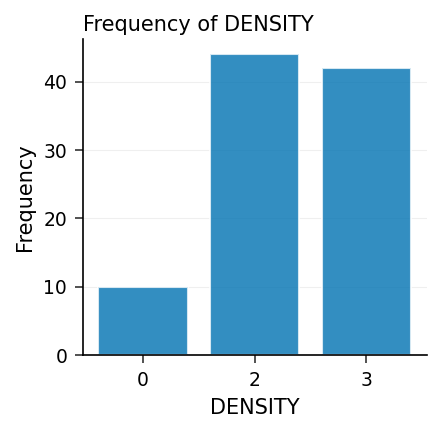

In [2]:
PROCEDUR GREDUCE data=zonemap out=reducedmap;
    id zone;
KÖR;

PROCEDUR FREKVENSER data=reducedmap;
    TABLES DENSITY / nocum;
    TITEL 'Gränspunkter som behålls på varje DENSITY-nivå';
KÖR;

## Steg 3 – Granska densitetsnivåerna

Frekvenstabellen visar hur GREDUCE graderade de 96 gränspunkterna:

| DENSITY | Punkter | Andel |
|---------|--------|-------|
| 0 | 10 | 10,4 % |
| 2 | 44 | 45,8 % |
| 3 | 42 | 43,8 % |

Endast 10 punkter har den lägsta nivån (förankringspunkterna för den väsentliga formen), medan de återstående 86 fördelas mellan nivåerna 2 och 3. För en panelnivå behåller vi allt vid `DENSITY <= 2`: det behåller 54 av de 96 punkterna och tar bort de 42 finaste (`DENSITY=3`) hörnpunkterna. PROC MEANS nedan bekräftar att den grova nivån innehåller 13–14 hörnpunkter per zon i stället för de ursprungliga 24.

In [3]:
PROCEDUR MEDELVÄRDEN data=reducedmap n;
    KLASS zone;
    DÄR DENSITY <= 2;
    VARIABEL x;
    TITEL 'Hörnpunkter per zon vid paneldetalj (DENSITY <= 2)';
KÖR;

                                   Hörnpunkter per zon vid paneldetalj (DENSITY <= 2)                                   

                                                  The MEANS Procedure

                                                 Analysis Variable : X

        zone              N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Steg 4 – Bygg den grova kartan och prestationsdata per zon

Vi materialiserar panelnivån som `coarsemap` (`DENSITY <= 2`) så att PROC GMAP kan rita den reducerade konturen direkt. Vi genererar också en KPI-rad per zon — en **andel leveranser i tid** och en **daglig paketvolym** — nyckelkopplad på `zone` så att GMAP kan färglägga varje område.

In [4]:
data coarsemap;
    STÄLL_IN reducedmap;
    DÄR DENSITY <= 2;
KÖR;

data zonekpi;
    CALL streaminit(771);
    GÖR zone = 1 TILL 4;
        /* andel i tid centrerad nära 92%, realistisk spridning */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        UTDATA;
    SLUT;
KÖR;

PROCEDUR SKRIV data=zonekpi noobs;
    TITEL 'Syntetiska leverans-KPI:er per zon';
KÖR;

                                           Syntetiska leverans-KPI:er per zon                                           

zone  ontime_rate  parcels
   1         92.6     4704
   2         95.6     2932
   3         93.4     2934
   4         94.6     2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


De fyra syntetiska andelarna för leverans i tid hamnar mellan 92,6 % och 95,6 %, med dagliga paketvolymer från cirka 2 500 till 4 700. Zon 2 presterar starkast med 95,6 %; zon 1 är svagast med 92,6 %. Det är dessa värden choropletkartans färgband kodar.

## Steg 5 – Rita choropletkartor med full detalj kontra reducerad detalj

Vi ritar samma choropletkarta för leverans i tid två gånger: en gång från den fullständiga 96-hörnpunkts-`reducedmap` och en gång från den 54-hörnpunkts-`coarsemap`. `MAP=` anger gränserna, `DATA=` KPI-svaret, och båda delar `zone`-ID:t. Satsen `CHORO` fyller varje zon efter `ontime_rate` med `LEVELS=4` färgband och `COUTLINE=` för skarpa konturer. Att jämföra de två kartorna visar vad reduktionen kostar visuellt.

                                              Full detalj: 96 gränspunkter                                              




NOTE: Option TITLE changed to Full detalj: 96 gränspunkter.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable ontime_rate.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.44 seconds
  cpu   0.44 seconds


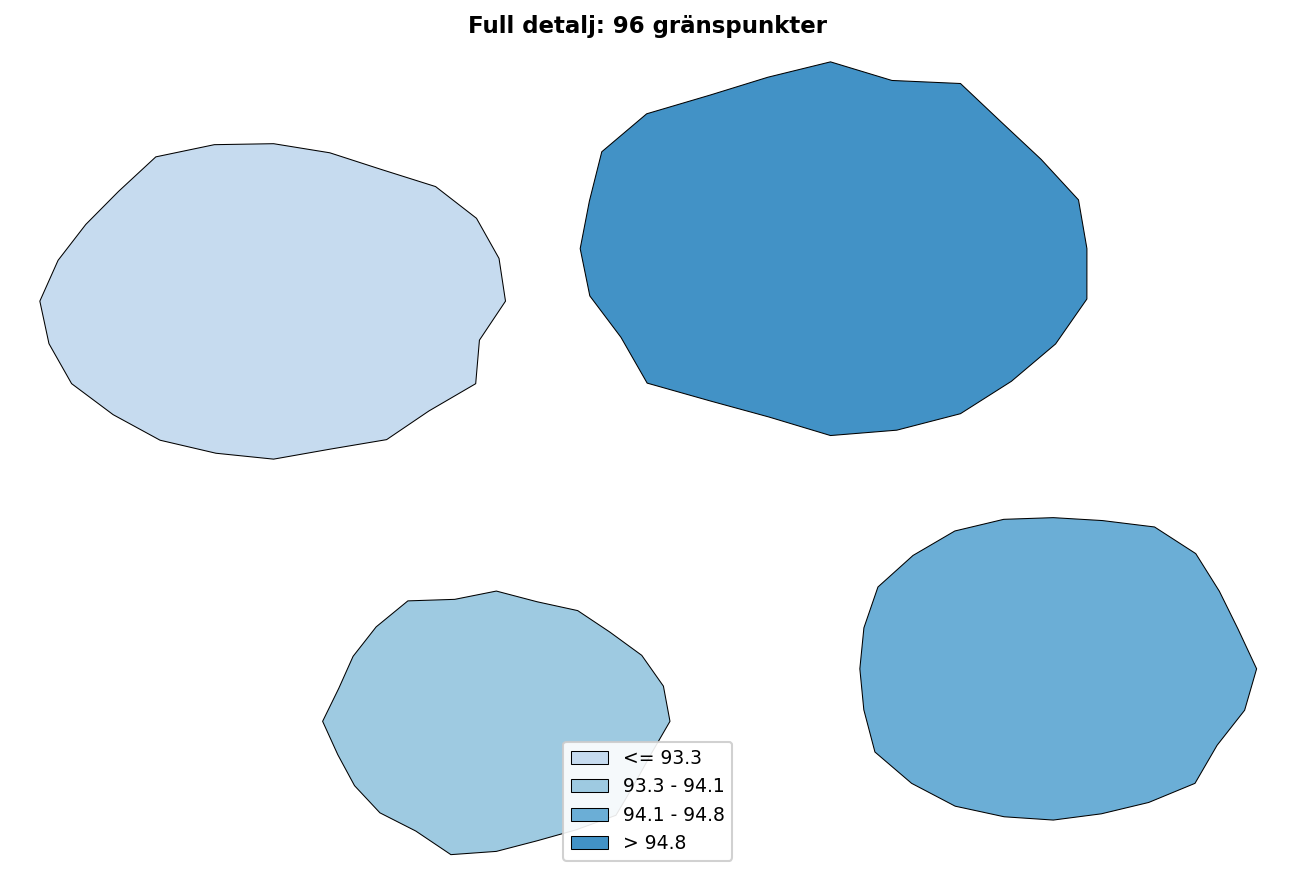

In [5]:
TITEL 'Full detalj: 96 gränspunkter';
PROCEDUR GMAP map=reducedmap data=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
KÖR;

                                    Reducerad detalj: 54 hörnpunkter (DENSITY <= 2)                                     




NOTE: Option TITLE changed to Reducerad detalj: 54 hörnpunkter (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable ontime_rate.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.46 seconds
  cpu   0.46 seconds


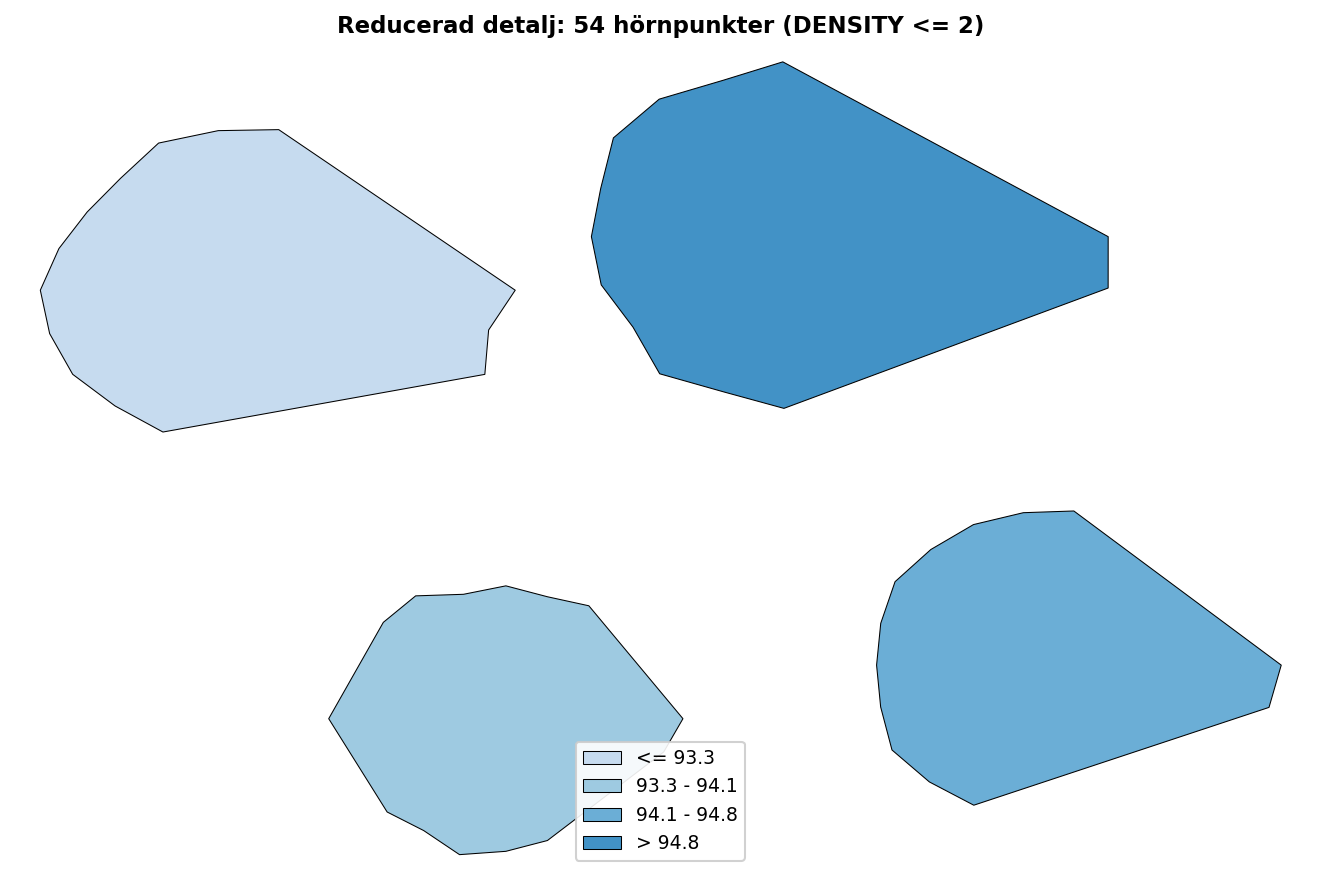

In [6]:
TITEL 'Reducerad detalj: 54 hörnpunkter (DENSITY <= 2)';
PROCEDUR GMAP map=coarsemap data=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
KÖR;

## Tolkning av resultaten

PROC GREDUCE omvandlade varje 24-hörnpunkts zonkontur till en graderad uppsättning gränspunkter (nivåerna 0, 2 och 3 i den här körningen). Att välja nivån `DENSITY <= 2` minskade kartan från 96 hörnpunkter till 54 — en 44-procentig minskning av de punkter renderaren måste rita — men choropletkartorna sida vid sida bekräftar att de fyra zonerna förblir tydligt igenkännbara: den reducerade kartans konturer är synligt mer kantiga, men varje territorium behåller sin position, storlek och färgband, så en operatör läser samma resultattavla oavsett vilken karta som visas.

Den resultattavlan rangordnar zonerna efter andel leveranser i tid: zon 2 leder med 95,6 % (mörkaste bandet), zonerna 3 och 4 ligger i mittfältet nära 93–95 %, och zon 1 kommer sist med 92,6 % (ljusaste bandet) — det territorium en planerare först skulle undersöka för rutt- eller depåkapacitetsproblem.

Eftersom reduktionen inte är destruktiv — punkterna med full detalj finns kvar i `reducedmap` — stöder samma dataset både den snabba panelvyn (`DENSITY <= 2`) och en högupplöst utskrifts- eller granskningsvy (`DENSITY <= 3`, eller hela mängden) genom att bara ändra ett enda `WHERE`-tröskelvärde, utan att behöva importera eller reducera geometrin på nytt.